#5-1. DBSCAN의 개요

##5-1-1. DGSCAN 개요

- 밀도 기반 군집화의 대표적인 알고리즘인 DBSCAN은 간단하고 직관적인 알고리즘으로 돼있음에도 데이터의 분포가 기하학적으로 복잡한 데이터 세트에도 효과적인 군집화가 가능하다.
- 내부의 원 모양과 외부의 원 모양 형태의 분포를 가진 데이터 세트를 군집화한다고 가정할 때 앞에서 소개한 K평균,평균 이동, GMM으로는 효과적인 군집화를 수행하기 어렵다
- DBSCAN은 특정 공간 내에 데이터 밀도 차이를 기반 알고리즘으로 하고 있어서 복잡한 기하학적 분포도를 가진 데이터 세트에 대해서도 군집화를 잘 수행한다.
- DBSCAN을 구성하는 가장 중요한 두 가지 파라미터는 입실론으로 표기하는 주변 영역과 이 입실론 주변 영역에 포함되는 최소 데이터 개수 min point이다.
- 입실론 주변 영역 내에 포함되는 최소 데이터 개수를 충족시키는가 아닌가에 따라 데이터 포인트를 다음과 같이 정의한다.
  + 핵심 포인트: 주변 영역 내에 최소 데이터 개수 이상의 타 데이터를 가지고 있을 경우
  + 이웃 포인트: 주변 영역 내에 위치한 타 데이터
  + 경계 포인트: 주변 영역 내에 최소 데이터 개수 이상의 이웃 포인트를 가지고 있지 않지만 핵심 포인트를 이웃 포인트로 가지고 있는 데이터
  + 잡음 포인트: 최소 데이터 개수 이상의 이웃 포인트를 가지고 있지 않으며, 핵심 포인트도 이웃 포인트로 가지고 있지 않는 데이터
- DBSCAN은 입실론 주변 영역의 최소 데이터 개수를 포함하는 밀도 기준을 충족시키는 데이터는 핵심 포인트를 연결하면서 군집화를 구성한다.
- 사이킷런의 DBSCAN 클래스를 통해 DBSCAN 알고리즘을 지원한다.
  + eps: 입실론 주변 영역의 반경
  + min_samples: 핵심 포인트가 되기 위해 입실론 주변 영역 내에 포함되어야 할 데이터의 최소 개수 (자신의 데이터를 포함함)

##5-1-2. DBSCAN 적용하기 - 붓꽃 데이터 세트

- DBSCAN 클래스를 이용해 붓꽃 데이터 세트를 군집화한다
- 일반적으로 eps 값은 1이하의 값을 설정한다.

In [45]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the iris dataset
iris = load_iris()

# Create a DataFrame for iris data
irisDF = pd.DataFrame(data=iris.data, columns=iris.feature_names)

from sklearn. cluster import DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples =8, metric = 'euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)
irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby (['target'])['dbscan_cluster'].value_counts()
print(iris_result)

target  dbscan_cluster
0        0                49
        -1                 1
1        1                46
        -1                 4
2        1                42
        -1                 8
Name: count, dtype: int64


- dbcsan_cluster 값을 살펴보면 0과 1 외에 특이하게 -1이 군집 테이블로 있다.
- 군집 레이블이 -1인 것은 노이즈에 속하는 군집이다.
- 0과 1 두 개의 군집으로 군집화했다.
- Target 값의 유형이 3가지인데, 군집에 2개가 됐다고 군집화 효율이 떨어지는 것은 아니다.
- DBSCAN은 군집의 개수를 알고리즘에 따라 자동으로 저장하므로 DBSCAN에서 군집 개수를 지정하는 것은 무의미하다.
- DBSCAN으로 군집화 데이터 세트를 2차원 평면에서 표현하기 위해 PCA를 이용해 2개의 피처로 압축 변환한 뒤, 앞 예제에서 사용한 visualize_cluster_plot() 함수를 이용해 시각화한다
- visualize_cluster_plot() 함수 인자로 사용하기 위해 irisDF의 'ft1','ft2' 칼럼에 PCA로 변환된 피처 데이터 세트를 입력한다.

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

%matplotlib inline

def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
    if dataframe is None:
        print("Error: DataFrame is required.")
        return
    unique_labels = np.unique(dataframe[label_name])
    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']
    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name] == label]
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
                    marker=markers[label % len(markers)])
        if iscenter and cluster_result is not None and hasattr(cluster_result, 'cluster_centers_'):
            # Assuming cluster_result has a .cluster_centers_ attribute
            center_x_y = cluster_result.cluster_centers_[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
                        marker=markers[label % len(markers)])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',
                        marker='$%d$' % label)
    plt.show()

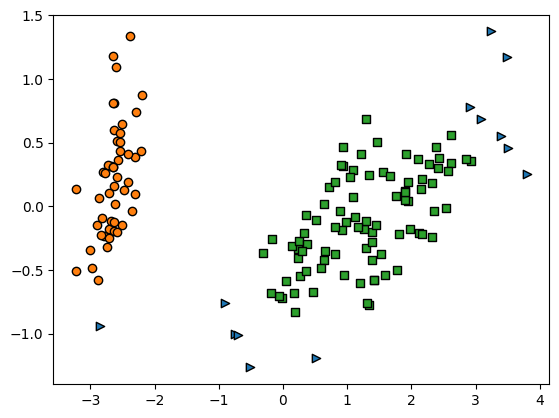

In [47]:
from sklearn. decomposition import PCA

#2차원으로 시각화하기 위해 PCA n_components=2로 피처 데이터 세트 변환
pca = PCA(n_components=2, random_state=0)
pca_transformed = pca.fit_transform(iris.data)
#visualize_cluster_plot() 함수는 ftr1, ftr2 칼럼을 좌표에 표현하므로 PCA 변환값을 해당 칼럼으로 생성
irisDF['ftr1'] = pca_transformed [:,0]
irisDF['ftr2'] = pca_transformed[:,1]

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster',iscenter=False)

- PCA로 2차원을 표현하면 이상치인 노이즈 데이터가 명확히 드러난다.
- DBSCAN을 적용할 때는 특정 군집 개수로 군집을 강제하지 않는 것이 좋다.
- eps의 값을 크게 하면 반경이 커져 포함하는 데이터가 많아지므로 노이즈 데이터 개수가 작아진다.
- min_samples를 크게 하면 주어진 반경 내에서 더 많은 데이터를 포함시켜야 하므로 노이즈 데이터 개수가 커지게 된다.
- eps를 기존의 0.6에서 0.8로 증가시키면 노이즈 데이터 수가 줄어든다.

target  dbscan_cluster
0        0                50
1        1                50
2        1                47
        -1                 3
Name: count, dtype: int64


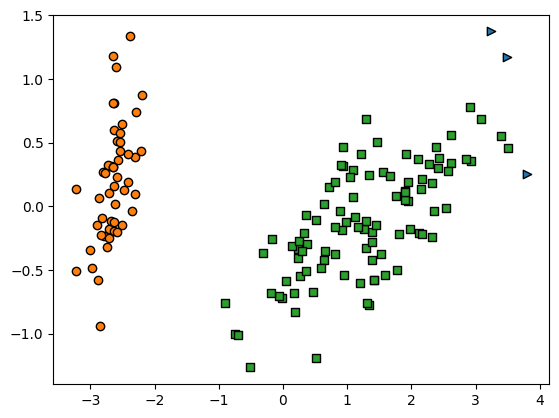

In [48]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples =8, metric = 'euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)
irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby (['target'])['dbscan_cluster'].value_counts()
print(iris_result)

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

- eps를 기존 0.6으로 유지하고 min_samples를 16으로 늘린다.

target  dbscan_cluster
0        0                48
        -1                 2
1        1                44
        -1                 6
2        1                36
        -1                14
Name: count, dtype: int64


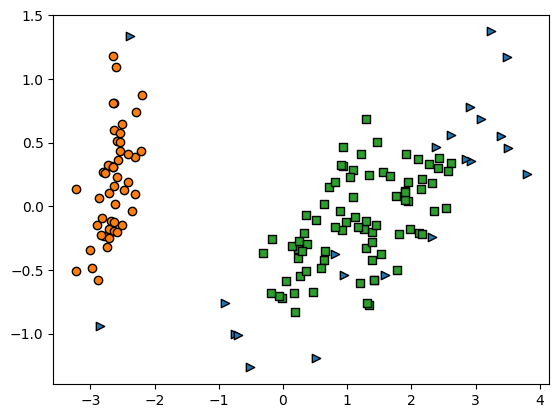

In [49]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN (eps=0.6, min_samples =16, metric = 'euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)
irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby (['target'])['dbscan_cluster'].value_counts()
print(iris_result)

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

##5-1-3. DBSCAN 적용하기 - make_series() 데이터 세트

- 복잡한 기하학적 분포를 가지는 데이터 세트에서 DBSCAN과 타 알고리즘을 비교해본다.
- make_circles() 함수를 이용해 내부 원과 외부 원 형태로 돼 있는 2차원 데이터 세트를 만들어본다.
- make_circles() 함수는 오직 2개의 피처만을 생성하므로 별도의 피처 개수를 지정할 필요가 없다.
- 파라미터 noise는 노이즈 데이터 세트의 비율이며, factor는 외부 원과 내부 원의 scale 비율이자.

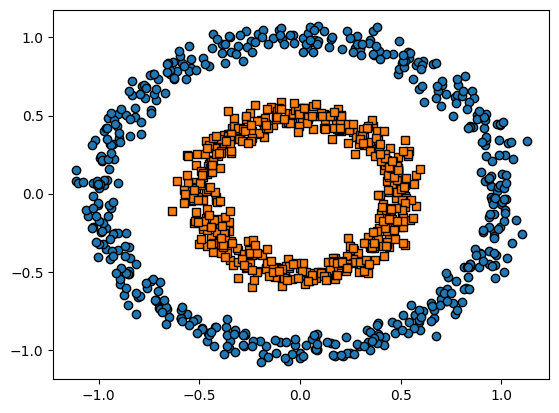

In [50]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, shuffle = True, noise= 0.05, random_state=0, factor=0.5)
clusterDF = pd.DataFrame(data= X, columns=['ftr1','ftr2'])
clusterDF['target'] =y

visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

- make_circles()는 내부 원과 외부 원으로 구분되는 데이터 세트를 생성함
- K- 평균으로 make_circles() 데이터 세트를 군집화한다.

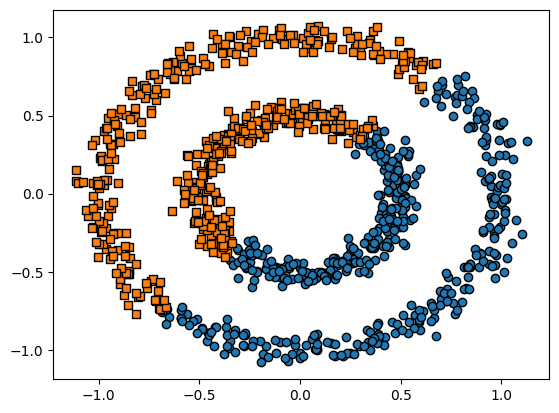

In [51]:
#KMeans로 make_circles() 데이터 세트를 군집화 수행
from sklearn.cluster import KMeans

kmeans= KMeans(n_clusters=2, max_iter=1000, random_state=0)
kmeans_labels= kmeans.fit_predict(X)
clusterDF['kmeans_cluster'] = kmeans_labels

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_cluster', iscenter= False)

- 위, 아래 군집 중심을 기반으로 우이ㅘ 아래 절반으로 군집화됐다.
- 거리 기반 군집화로는 위와 같이 데이터가 특정한 형태로 계속해서 이어지는 부분을 찾아내기 어렵다.
- GMM을 적용해본다.

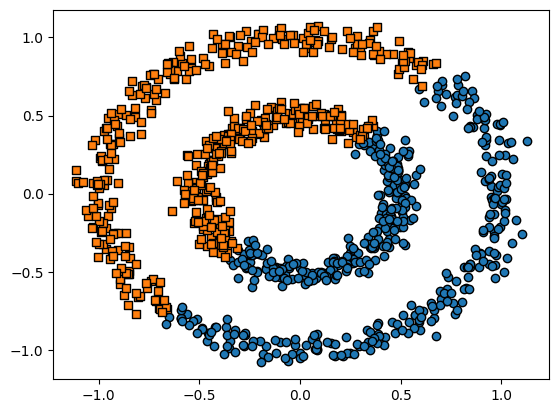

In [52]:
#GMM으로 make_circles() 데이터 세트를 군집화 수행
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=0)
gmm_label = gmm.fit(X). predict(X)
clusterDF['gmm_cluster'] = gmm_label

visualize_cluster_plot(gmm, clusterDF, 'gmm_cluster', iscenter=False)

- 내부와 외부의 원형으로 구성된 더 복잡한 형태의 데이터 세트에서는 군비화가 원하는 방향으로 되지 않는다.
- DBSCAN으로 군집화를 적용한다.

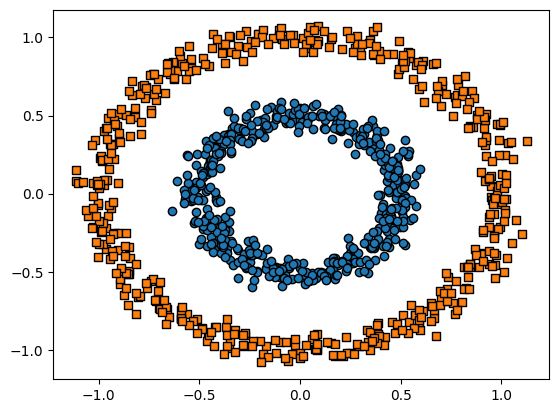

In [53]:
#DBSCAN으로 make_circles() 데이터 세트 군집화 수행
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=10, metric='euclidean')
dbscan_labels = dbscan.fit_predict(X)
clusterDF['dbscan_cluster'] = dbscan_labels
visualize_cluster_plot(dbscan, clusterDF, 'dbscan_cluster', iscenter=False)

- DBSCAN으로 군집화를 적용해 원하는 방향으로 정확히 군집화 되었다.

#5-2. 군집화 실습- 고객 세그먼테이션

##5-2-1. 고객 세그먼테이션의 정의와 기법

- 고객 세그먼테이션은 다양한 기준으로 고객을 분류하는 기법으로 CRM이나 마케팅의 중요 기반 요소이다.
- 기업 입장에서는 얼마나 많은 매출을 발생하느냐가 고객 기준을 정하는 중요한 요소이다.
- 고객 세그먼테이션의 주요 목표는 타겟 마케팅이다.
- 타겟 마케팅이란 고객을 여러 특성에 맞게 세분화해서 그 유형에 따라 맞춤형 마케팅이나 서비스를 제공하는 것이다.
- 고객 세그먼테이션은 고객의 어떤 요소를 기반으로 군집화할 것인가를 결정하는 것이 중요한데, 여기서는 기본적인 고객 분석 요소인 RFM 기법을 이용한다.
  - RECENCY: 가장 최근 상품 구입 일에서 오늘까지의 기간
  - FREQUENCY: 상품 구매 횟수
  - MONETARY VALUE: 총 구매 금액
- 온라인 판매 데이터를 기반으로 고객 세그먼테이션을 군집화 기반으로 수행한다.

## 5-2-2. 데이터 세트 로딩과 데이터 클렌징

- 새로운 주피터 노트북을 생성하고 해당 엑셀 파일을 주피터 노트북이 생성한 디렉토리로 저장한다.
- 엑셀 파일을 판다스의 read_excel() 함수를 이용해 DataFrame으로 로드해본다.

In [54]:
import pandas as pd
import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from google.colab import drive
drive.mount('/content/drive')
file_path= '/content/drive/MyDrive/Online Retail.xlsx'
retail_df = pd.read_excel(file_path)
retail_df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


- 이 데이터 세트는 제품 주문 데이터 세트이다.
- Invoice(주문번호) + StockCode(제품코드)를 기반으로 주문량, 주문 일자, 제품 단가, 주문 고객 번호, 주문 고객 국가 등의 칼럼으로 구성되어 있다.
- 데이터 세트의 전체 건수, 칼럼 타입, Null 개수를 확인해본다.

In [55]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


- 이 데이터 세트는 사전 정제 작업이 필요하다.
- Null 데이터 제거: 특히 CustomerID가 Null인 데이터가 많다. 고객 세그먼테이션을 수행하므로 고객 식별 번호가 없는 데이터는 필요 없기에 삭제한다.
- 오류 데이터 삭제: 대표적인 오류 데이터는 Quantitiy 또는 UnitPrice가 0보다 작은 경우이다. Quality가 0보다 작은 경우는 오류 데이터라기 보다는 반환을 뜻하는 값이다. 이 경우 InvoiceNo의 앞자리는 'C'로 되어 있다. 분석의 효율성을 위해 이 데이터는 모두 삭제한다.
- 불린 인덱싱을 적용해 Quantity >0 , UnitPrice >0이고 CustomerID가 Not Null인 값만 다시 필터링한다.

In [56]:
retail_df=retail_df[retail_df['Quantity']>0]
retail_df=retail_df[retail_df['UnitPrice']>0]
retail_df=retail_df[retail_df['CustomerID'].notnull()]
print(retail_df.shape)
retail_df.isnull().sum()

(397884, 8)


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


- 주요 주문 고객은 영국인데, 이 외에도 EU 여러 나라의 영연방 국가들이 포함돼있다.

In [57]:
retail_df['Country'].value_counts()[:5]

,count
Country,
United Kingdom,354321
Germany,9040
France,8341
EIRE,7236
Spain,2484


- 영국이 대다수를 차지하므로 다른 국가의 데이터는 모두 제외한다.

In [58]:
retail_df = retail_df[retail_df['Country'] == 'United Kingdom']
print(retail_df.shape)

(354321, 8)


##5-2-3. RFM 기반 데이터 제공

- 사전 정제된 데이터 기반으로 고객 세그먼테이션 군집화를 RFM 기반으로 수행하기 위해 필요한 데이터를 가공한다.
- 'UnitPrice'와 'Quantity'를 곱해서 주문 금액 데이터를 만든다.
- CustomerNo도 더 편리한 식별성을 위해 float형을 int형으로 변경한다.

In [59]:
retail_df['sale_amount']=retail_df['Quantity']*retail_df['UnitPrice']
retail_df['CustomerID']=retail_df['CustomerID'].astype(int)

- Top-5 주문 건수와 주문 금액을 가진 고객 데이터를 추출해본다.

In [66]:
print(retail_df['CustomerID'].value_counts().head(5))
print(retail_df.groupby('CustomerID')['sale_amount'].sum().sort_values(ascending=False).iloc[:5])

CustomerID
17841    7847
14096    5111
12748    4595
14606    2700
15311    2379
Name: count, dtype: int64
CustomerID
18102    259657.30
17450    194550.79
16446    168472.50
17511     91062.38
16029     81024.84
Name: sale_amount, dtype: float64


- 몇몇 특정 고객이 많은 주문 건수와 주문 금액을 가지고 있다.
- InvoiceNo + StockCode로 Group by를 수행하면 거의 1에 가깝게 유일한 깃별자 레벨이 된다.

In [62]:
retail_df.groupby(['InvoiceNo','StockCode'])['InvoiceNo'].count().mean()

np.float64(1.028702077315023)

- RFM 기반의 고객 세그먼테이션은 고객 레벨로 주문 기간, 주문 횟수, 주문 금액 데이터를 기반으로 해 세그먼테이션을 수행하는 것이다.
- 주문번호 + 상품코드 기준의 데이터를 고객 기준의 Recency, Frequency, Monetary value 데이터로 변경하는데 이를 위해서는 주문번호 기준의 데이터를 개별 고객 기준의 데이터로 Group by 해야 한다.
- 주문번호 기준의 retail_df DataFrame에 groupby('CustomerID')를 적용해 CustomerID 기준으로 DataFrame을 새롭게 생성한다.
- DataFrame에 groupby를 호출해 반환된 DataFrameGroupby 객체에 agg()를 이용한다.
- agg()에 인자로 대상 칼럼들과 aggregation 함수명들을 딕셔너리 형태로 입력하면 컬럼 여러 개의 서로 다른 aggregation 연산을 쉽게 수행할 수 있다.
- Frequancy는 고객별 주문 건수이므로 'CustomerID'로 groupby() 해서 'InvoiceNo'의 count() aggregation으로 구한다.
- Monetary value는 고객별 주문 금액이므로 'CustomerID'로 groupby()해서 'sale_amount'의 sum() aggregation으로 구한다.
- Recency의 경우 'CustomerID'로 groupby() 해서 'InvoiceDate' 칼럼의 max()로 고객별 가장 최근 주문 일자를 먼저 구한 뒤 추후에 가공 작업을 별도로 수행한다.

In [64]:
#DataFrame의 groupby()의 multiple연산을 위해 agg() 이용
#Recency는 InvoiceDate 칼럼의 max()에서 데이터 가공
#Frequency는 InvoiceNo  칼럼의 count(), Monetary value는 sale_amount 칼럼의 sum()
aggregations= {'InvoiceDate':'max','InvoiceNo':'count','sale_amount':'sum'}
cust_df = retail_df.groupby('CustomerID').agg(aggregations)

#groupby된 결과 칼럼 값을 Recency, Frequency, Monetar로 변경
cust_df = cust_df.rename(columns= {'InvoiceDate':'Recency','InvoiceNo':'Frequency','sale_amount':'Monetary'})
cust_df = cust_df.reset_index()
cust_df.head(3)

,CustomerID,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,1,77183.60
1,12747,2011-12-07 14:34:00,103,4196.01
2,12748,2011-12-09 12:20:00,4595,33719.73


- Recency는 고객이 가장 최근에 주문한 날짜를 기반으로 하는데, 오늘 날짜를 기준으로 가장 최근 주문 일자를 뺀 날짜이다.
- 2011년 12월 10일을 현재 날짜로 간주하고 가장 최근의 주문 일자를 뺀 데이터에서 일자 데이터(days)만 추출해 생성한다.

In [65]:
import datetime as dt

cust_df['Recency'] = dt.datetime(2011,12,10) -cust_df['Recency']
cust_df['Recency']=cust_df['Recency'].apply(lambda x: x.days+1)
print('cust_df 로우와 칼럼 건수는', cust_df.shape)
cust_df.head(3)

cust_df 로우와 칼럼 건수는 (3920, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,3,103,4196.01
2,12748,1,4595,33719.73


##5-2-4. RFM 기반 고객 세그먼테이션

- 온라인 판매 데이터 세트는 소매업체의 대규모 주문을 포함하고 있다.
- 이들은 주문 횟수와 주문 금액에서 개인 고객 주문과 매우 큰 차이를 나타내고 있으며 이로 인해 매우 왜곡된 데이터 분포도를 가지게 되어 군집화가 한쪽 군집에만 집중되는 형상이 발생하게 된다.
- 오라인 판매 데이터 세트의 칼럼별 히스토그램을 확인하고, 이처럼 왜곡된 데이터 분포도에서 군집화를 수행할 때 어떤 현상이 발생하는지 알아본다.
- 'Recency','Frequency','Monetary' 칼럼 별 분포 히스토그램을 나타낸다.
- 맷플롯립의 hist()를 이용해 각 컬럼의 값 분포도를 알아본다.

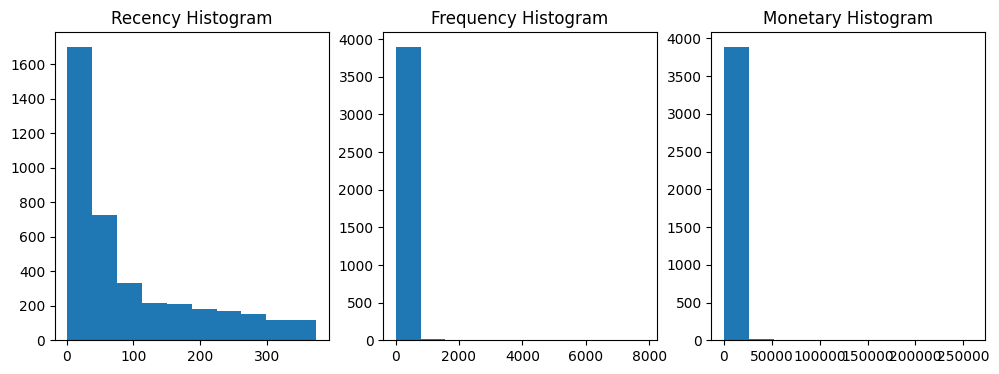

In [67]:
fig, (ax1, ax2, ax3) = plt. subplots(figsize=(12,4), nrows=1, ncols=3)
ax1.set_title('Recency Histogram')
ax1.hist(cust_df['Recency'])

ax2.set_title('Frequency Histogram')
ax2.hist(cust_df['Frequency'])

ax3.set_title('Monetary Histogram')
ax3.hist(cust_df['Monetary'])
plt.show()

- Recency,Frequency,Monetary 모두 왜곡된 데이터 값 분포도를 가지고 있으며, 각 칼럼의 데이터 값 백분위로 대략적으로 어떻게 값이 분포돼 있는지 확인한다.

In [69]:
cust_df[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000
mean,92.742092,90.388010,1864.385601
std,99.533485,217.808385,7482.817477
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,300.280000
50%,51.000000,41.000000,652.280000
75%,143.000000,99.250000,1576.585000
max,374.000000,7847.000000,259657.300000


- 왜곡 정도가 매우 높은 데이터 세트에 K-평균 군집을 적용하면 중심의 개수를 증가시키더라도 변별력이 떨어지는 군집화가 수행된다.
- 데이터 세트를 StandardScaler로 평균과 표준편차를 재조정한 뒤에 K-평균을 수행해본다.

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

X_features = cust_df[['Recency','Frequency','Monetary']].values
X_features_scaled = StandardScaler().fit_transform(X_features)

kmeans =KMeans(n_clusters=3, random_state=0)
labels= kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label']= labels

print('실루엣 스코어는 : {0:.3f}'.format(silhouette_score(X_features_scaled, labels)))

실루엣 스코어는 : 0.576


- 군집을 3개로 구성할 경우 전체 군집의 평균 실루엣 계수인 실루엣 스코어는 0.592로 안정적인 수치가 나왔다.
- visualize_silhouette() 함수와 군집 개수별로 군집화 구성을 시각화하는 visualize_kmeans_plot_multi() 함수를 새롭게 생성하여 군집 개수를 2~5개까지 변화시키면서 개별 군비의 실루엣 계수 값돠 데이터 구성을 함께 알아본다.

In [72]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA


def visualize_silhouette(cluster_lists, X_features):
    # Visualize Silhouette for each cluster_lists
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)
    for ind, n_cluster in enumerate(cluster_lists):
        kmeans = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0, n_init='auto')
        cluster_labels = kmeans.fit_predict(X_features)
        silhouette_avg = silhouette_score(X_features, cluster_labels)
        sample_silhouette_values = silhouette_samples(X_features, cluster_labels)
        y_lower = 10
        axs[ind].set_title('Number of Cluster : ' + str(n_cluster) + '\n' \
                           'Silhouette Score :' + str(round(silhouette_avg, 3)))
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        for i in range(n_cluster):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()
            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, \
                                   facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
        axs[ind].axvline(x=silhouette_avg, color="red", linestyle="--")

    plt.tight_layout()
    plt.show()

def visualize_kmeans_plot_multi(cluster_lists, X_features, iscenter=False):
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)
    pca = PCA(n_components=2, random_state=0)
    pca_transformed = pca.fit_transform(X_features)
    dataframe = pd.DataFrame(data=pca_transformed, columns=['ftr1', 'ftr2'])
    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

    for ind, n_cluster in enumerate(cluster_lists):
        kmeans = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0, n_init='auto')
        cluster_labels = kmeans.fit_predict(X_features)
        dataframe['cluster'] = cluster_labels
        unique_labels = np.unique(dataframe['cluster'])

        for label in unique_labels:
            label_cluster = dataframe[dataframe['cluster'] == label]
            axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
                             marker=markers[label % len(markers)])

        if iscenter and hasattr(kmeans, 'cluster_centers_'):
            center_x_y = pca.transform(kmeans.cluster_centers_)

            for label, center in enumerate(center_x_y):
                axs[ind].scatter(x=center[0], y=center[1], s=200, color='gray', alpha=0.9,
                                 marker=markers[label % len(markers)])
                axs[ind].scatter(x=center[0], y=center[1], s=70, color='k', edgecolor='k',
                                 marker='$%d$' % label)

        axs[ind].set_title('Number of Cluster : ' + str(n_cluster))
        axs[ind].set_xlabel('ftr1')
        axs[ind].set_ylabel('ftr2')

    plt.tight_layout()
    plt.show()

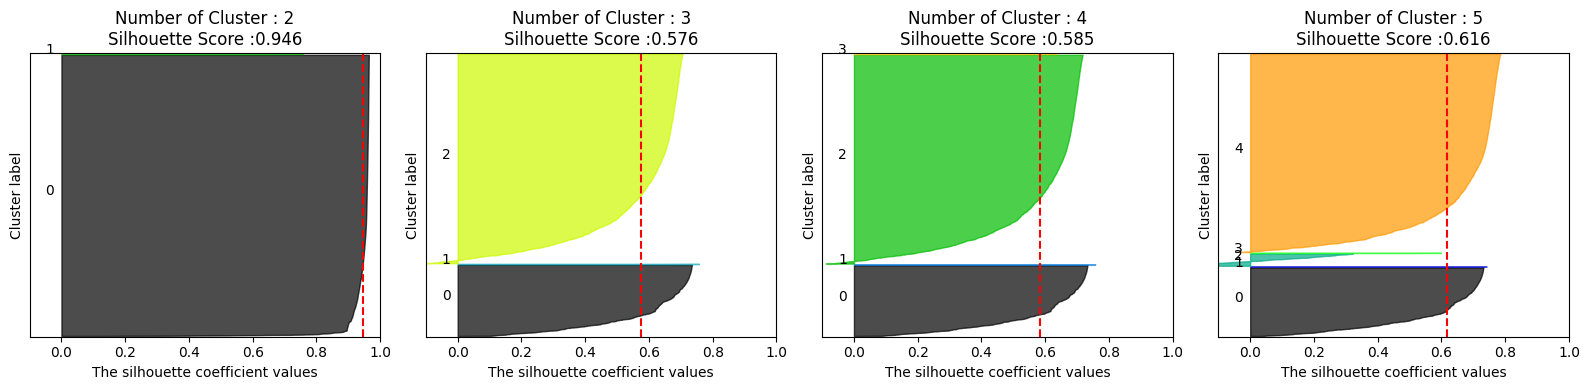

/tmp/ipython-input-2301801243.py:60: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
/tmp/ipython-input-2301801243.py:60: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',


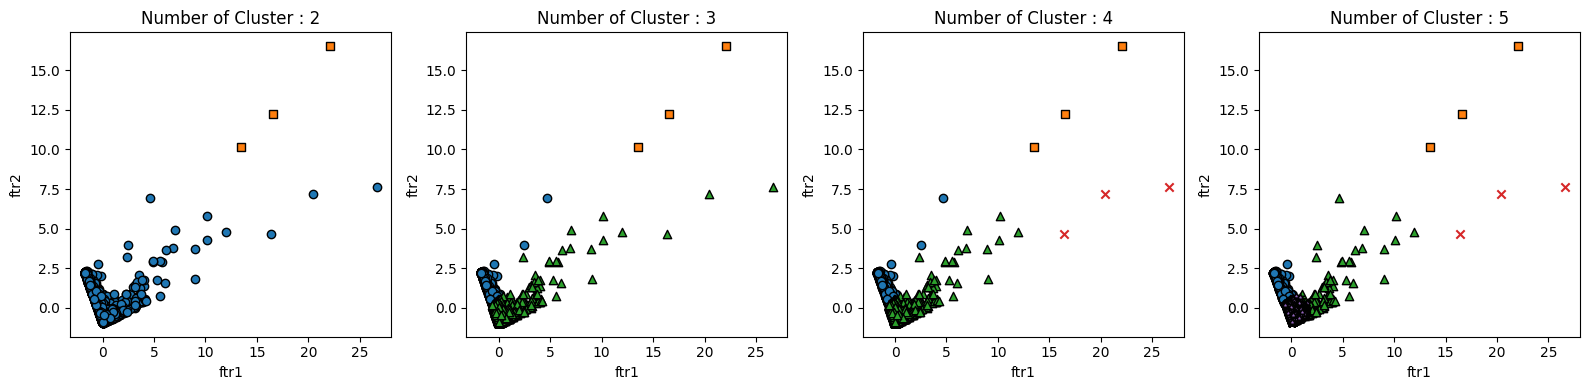

In [75]:
visualize_silhouette([2,3,4,5], X_features_scaled)
visualize_kmeans_plot_multi([2,3,4,5], X_features_scaled)

- 군집이 2개인 경우 0번 군집과 1번 군집이 너무 개괄적으로 군집화됐다.
- 군집 수를 증가시키면 개선이 가능할 것 같았는데, 실제 결과는 달랐다.
- 군집이 3개 이상일 때부터는 데이터 세트의 개수가 너무 작은 군집이 만들어진다.
- 이 군집에 속한 데이터는 개수가 작을뿐더러 실루엣 계수 역시 상대적으로 매우 작다.
- 군집 내부에서도 데이터가 광범위하게 퍼져있다.
- 소수의 데이터 세트는 바로 앞에서 왜곡된 데이터 값인 특정 소매점의 대량 주문 구매 데이터이다.
- 이 데이터 세트의 경우 데이터 값이 거리 기반으로 광범위하게 퍼져 있어서 군집 수를 계속 늘려봐야 이 군집만 지속적으로 분리하게 되기에 의미 없는 군집화 결과로 이어진다.
- 지나치게 왜곡된 데이터 세트는 K-평균과 같은 거리 기반 군집화 알고리즘에서 지나치게 일반적인 군집화 결과를 도출하게 된다.
- 데이터 세트의 왜곡 정도를 낮추기 위해 가장 자주 사용되는 방법은 데이터 값에 로그를 적용하는 로그 변환이다.
- 온라인 판매 데이터 세트의 왜곡 정도를 낮추기 위해 전체 데이터를 로그 변환한 뒤에 K-평균 알고리즘을 적용하고 결과를 비교해본다.

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

#Recency,Frequency,Monetary 칼럼에 np.log1p()로 Log Transformation
cust_df['Recency_log'] =np.log1p(cust_df['Recency'])
cust_df['Frequency_log'] =np.log1p(cust_df['Frequency'])
cust_df['Monetary_log'] =np.log1p(cust_df['Monetary'])

#Log Transformation 데이터에 StandardScaler 적용
X_features = cust_df[['Recency_log','Frequency_log','Monetary_log']].values
X_features_scaled = StandardScaler().fit_transform(X_features)

kmeans =KMeans(n_clusters=3, random_state=0)
labels= kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label']= labels

print('실루엣 스코어는 : {0:.3f}'.format(silhouette_score(X_features_scaled, labels)))

실루엣 스코어는 : 0.303


- 실루엣 스코어는 로그 변환하기 전보다 떨어지지만 실루엣 스코어의 절대치가 중요한 것은 아니고, 어떻게 개별 군집이 더 균일하게 나뉠 수 있는지가 더 중요하다.
- 로그 변환한 데이터 세트를 기반으로 실루엣 계수와 군집화 구성을 시각화해본다.

In [78]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA


def visualize_silhouette(cluster_lists, X_features):
    # Visualize Silhouette for each cluster_lists
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)
    for ind, n_cluster in enumerate(cluster_lists):
        kmeans = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0, n_init='auto')
        cluster_labels = kmeans.fit_predict(X_features)
        silhouette_avg = silhouette_score(X_features, cluster_labels)
        sample_silhouette_values = silhouette_samples(X_features, cluster_labels)
        y_lower = 10
        axs[ind].set_title('Number of Cluster : ' + str(n_cluster) + '\n' \
                           'Silhouette Score :' + str(round(silhouette_avg, 3)))
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        for i in range(n_cluster):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()
            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, \
                                   facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
        axs[ind].axvline(x=silhouette_avg, color="red", linestyle="--")

    plt.tight_layout()
    plt.show()

def visualize_kmeans_plot_multi(cluster_lists, X_features, iscenter=False):
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)
    pca = PCA(n_components=2, random_state=0)
    pca_transformed = pca.fit_transform(X_features)
    dataframe = pd.DataFrame(data=pca_transformed, columns=['ftr1', 'ftr2'])
    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

    for ind, n_cluster in enumerate(cluster_lists):
        kmeans = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0, n_init='auto')
        cluster_labels = kmeans.fit_predict(X_features)
        dataframe['cluster'] = cluster_labels
        unique_labels = np.unique(dataframe['cluster'])

        for label in unique_labels:
            label_cluster = dataframe[dataframe['cluster'] == label]
            axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
                             marker=markers[label % len(markers)])

        if iscenter and hasattr(kmeans, 'cluster_centers_'):
            center_x_y = pca.transform(kmeans.cluster_centers_)

            for label, center in enumerate(center_x_y):
                axs[ind].scatter(x=center[0], y=center[1], s=200, color='gray', alpha=0.9,
                                 marker=markers[label % len(markers)])
                axs[ind].scatter(x=center[0], y=center[1], s=70, color='k', edgecolor='k',
                                 marker='$%d$' % label)

        axs[ind].set_title('Number of Cluster : ' + str(n_cluster))
        axs[ind].set_xlabel('ftr1')
        axs[ind].set_ylabel('ftr2')

    plt.tight_layout()
    plt.show()

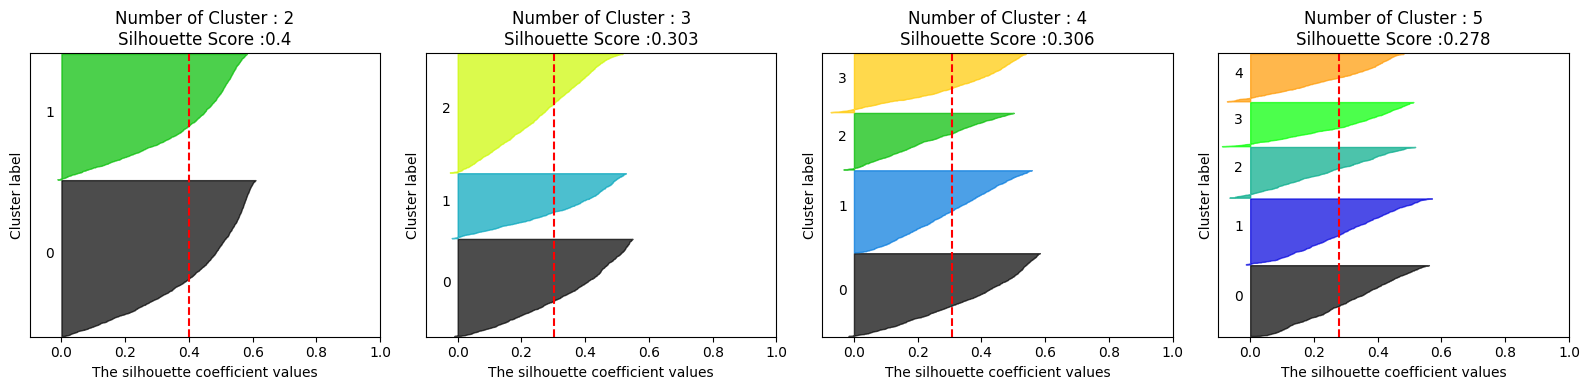

/tmp/ipython-input-2301801243.py:60: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
/tmp/ipython-input-2301801243.py:60: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',


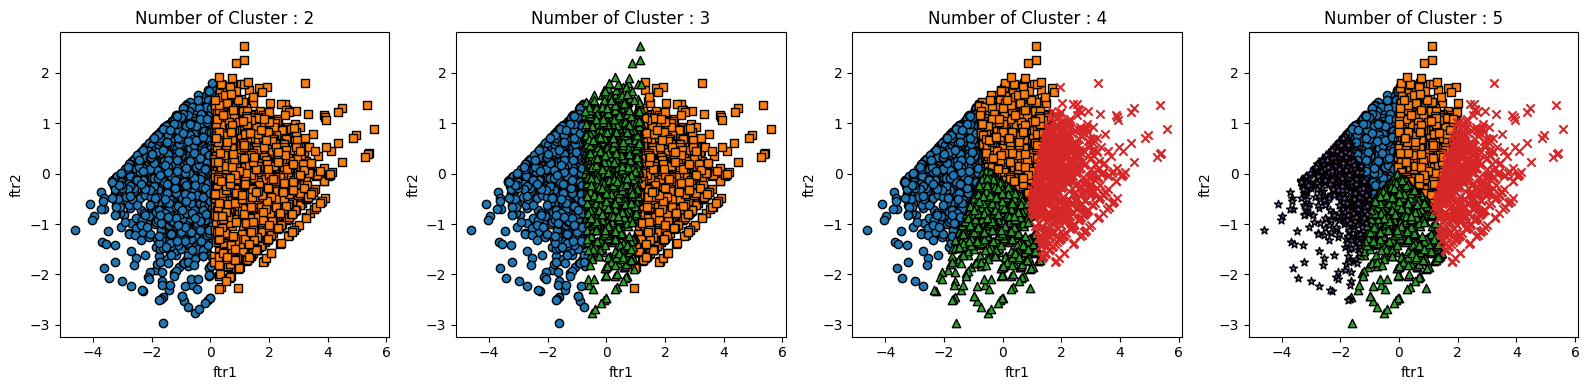

In [79]:
visualize_silhouette([2,3,4,5], X_features_scaled)
visualize_kmeans_plot_multi([2,3,4,5], X_features_scaled)

- 앞의 경우보다 더 균일하게 군집화가 구성되었다.
- 왜곡된 데이터 세트에 대해서는 로그 변환으로 데이터를 일차 변환한 후에 군집화를 수행하면 더 나은 결과를 도출할 수 있다.

#5-3. 정리
- 평균이동은 K-평균과 유사하지만 거리 중심이 아니라 데이터가 모여 있는 밀도가 가장 높은 쪽으로 군집 중심점을 이동하면서 군집화를 수행한다.
- GMM 군집화는 군집화를 적용하고자 하는 데이터가 여러 개의 가우시안 분포를 모델을 섞어서 생성된 모델로 가정해 수행하는 방식이다.
- DBSCAN은 밀도 기반 군집화의 대표적인 알고리즘이다.